# IT3051 Fundamentals of Data Mining — Algorithm 1: K-Means Clustering

## Project: Soft E-commerce Customer Segmentation and Retention Prioritization

### Purpose and Overview
This notebook implements **K-Means Clustering** as the hard-clustering benchmark for customer segmentation.

### Critical Group Constraint
- All models must consume the shared preprocessed data produced by `01_EDA_Preprocessing.ipynb`:
  - `data/processed/development_preprocessed.csv` (40,000 customers, 18 features + `customer_id`)
  - `data/processed/holdout_preprocessed.csv` (10,000 customers, 18 features + `customer_id`)
- `customer_id` is for alignment only and **MUST NOT** be passed to the clustering algorithm.
- Business variables (`customer_lifetime_value_usd`, `churn_risk_score`) are deliberately kept outside clustering and stored separately in the `*_business_data.csv` files.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)

import matplotlib.pyplot as plt
import joblib
import time
import json

In [2]:
RANDOM_STATE = 42
K_RANGE = range(2, 9)
SIL_SAMPLE = 10000

In [3]:
# Paths are relative to the notebooks/ folder
DEV_PATH = "../data/processed/development_preprocessed.csv"
HOLDOUT_PATH = "../data/processed/holdout_preprocessed.csv"

dev_df = pd.read_csv(DEV_PATH)
holdout_df = pd.read_csv(HOLDOUT_PATH)

# Keep customer_id separately for alignment; it must never enter the model matrix
dev_customer_id = dev_df["customer_id"]
holdout_customer_id = holdout_df["customer_id"]

X_dev = dev_df.drop(columns=["customer_id"])
X_hold = holdout_df.drop(columns=["customer_id"])

# Guard: CLV / churn_risk_score must never be clustering inputs
excluded_terms = ("clv", "customer_lifetime_value", "churn")
leaked_cols = [c for c in X_dev.columns if any(term in c.lower() for term in excluded_terms)]
assert not leaked_cols, f"Found excluded columns in feature matrix: {leaked_cols}"
assert "customer_id" not in X_dev.columns and "customer_id" not in X_hold.columns

# Guard: dev and holdout must expose identical features in identical order
assert list(X_dev.columns) == list(X_hold.columns), "Dev/holdout feature columns differ or are out of order"

print(f"X_dev shape:   {X_dev.shape}")
print(f"X_hold shape:  {X_hold.shape}")
print(f"Feature count: {X_dev.shape[1]}")

X_dev shape:   (40000, 18)
X_hold shape:  (10000, 18)
Feature count: 18


**Why `customer_id`, CLV, and `churn_risk_score` are excluded from the feature matrix:**

- `customer_id` is a unique identifier kept only so cluster assignments can be mapped back to individual customers after fitting. It carries no behavioral signal, and including it would corrupt distance-based clustering.
- `customer_lifetime_value_usd` and `churn_risk_score` are business outcome metrics, not behavioral inputs. If they were fed into the model, the clusters would partly be defined by the very metrics we want to use afterward to *profile and validate* those clusters — that's circular and would overstate how useful the segmentation actually is.
- Excluding them keeps K-Means focused purely on behavioral/engagement features (tenure, purchase activity, satisfaction, channel and device usage), so CLV and churn remain an independent lens for interpreting the resulting segments.

## 2. Baseline K-Means (K=2..8)

Fit a baseline K-Means model for every K in `K_RANGE` using a fixed configuration (`init='k-means++'`, `n_init=10`, `max_iter=300`, `random_state=RANDOM_STATE`). For each K we record inertia, three internal validation metrics (silhouette, Davies-Bouldin, Calinski-Harabasz), convergence/runtime diagnostics, and cluster-size balance, then use these to pick candidate K values for deeper analysis later.

In [4]:
import os

RESULTS_DIR = "../results/kmeans"
FIGURES_DIR = "../results/figures/kmeans"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)


def cluster_size_stats(labels):
    """Return (sizes_dict, min_cluster_pct, max_cluster_pct) for a label array."""
    sizes = pd.Series(labels).value_counts().sort_index()
    pct = sizes / sizes.sum() * 100
    return sizes.to_dict(), float(pct.min()), float(pct.max())

In [5]:
baseline_records = []
baseline_models = {}

for k in K_RANGE:
    start = time.time()
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    labels = model.fit_predict(X_dev)
    runtime_sec = time.time() - start

    silhouette = silhouette_score(
        X_dev, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE
    )
    db = davies_bouldin_score(X_dev, labels)
    ch = calinski_harabasz_score(X_dev, labels)
    sizes, min_pct, max_pct = cluster_size_stats(labels)

    baseline_records.append(
        {
            "K": k,
            "inertia": model.inertia_,
            "silhouette": silhouette,
            "davies_bouldin": db,
            "calinski_harabasz": ch,
            "n_iter_": model.n_iter_,
            "runtime_sec": runtime_sec,
            "cluster_sizes": sizes,
            "min_cluster_pct": min_pct,
            "max_cluster_pct": max_pct,
        }
    )
    baseline_models[k] = model

    print(
        f"K={k}: inertia={model.inertia_:,.1f} silhouette={silhouette:.4f} "
        f"db={db:.4f} ch={ch:,.1f} n_iter={model.n_iter_} runtime={runtime_sec:.2f}s"
    )

K=2: inertia=427,186.0 silhouette=0.1203 db=2.6792 ch=3,072.2 n_iter=9 runtime=0.38s


K=3: inertia=401,526.2 silhouette=0.0732 db=3.1726 ch=2,912.3 n_iter=29 runtime=0.28s


K=4: inertia=385,884.9 silhouette=0.0633 db=2.9784 ch=2,560.5 n_iter=45 runtime=0.38s


K=5: inertia=372,774.3 silhouette=0.0627 db=2.9299 ch=2,339.6 n_iter=57 runtime=0.45s


K=6: inertia=363,354.5 silhouette=0.0609 db=2.6816 ch=2,127.5 n_iter=39 runtime=0.70s


K=7: inertia=354,903.9 silhouette=0.0602 db=2.5816 ch=1,973.8 n_iter=105 runtime=0.88s


K=8: inertia=347,555.4 silhouette=0.0611 db=2.4643 ch=1,848.3 n_iter=71 runtime=1.14s


In [6]:
baseline_df = pd.DataFrame(baseline_records)

# Serialize cluster_sizes to a JSON string so the dict round-trips cleanly through CSV
baseline_results_df = baseline_df.copy()
baseline_results_df["cluster_sizes"] = baseline_results_df["cluster_sizes"].apply(json.dumps)
baseline_results_df.to_csv(f"{RESULTS_DIR}/kmeans_baseline_results.csv", index=False)

print(f"Saved baseline results to {RESULTS_DIR}/kmeans_baseline_results.csv")
baseline_df

Saved baseline results to ../results/kmeans/kmeans_baseline_results.csv


,K,inertia,silhouette,davies_bouldin,calinski_harabasz,n_iter_,runtime_sec,cluster_sizes,min_cluster_pct,max_cluster_pct
0,2,427185.982160,0.120339,2.679201,3072.196113,9,0.376513,"{0: 33342, 1: 6658}",16.6450,83.3550
1,3,401526.182839,0.073245,3.172631,2912.271062,29,0.280148,"{0: 6017, 1: 17130, 2: 16853}",15.0425,42.8250
2,4,385884.891010,0.063265,2.978350,2560.544432,45,0.380260,"{0: 5725, 1: 10756, 2: 12811, 3: 10708}",14.3125,32.0275
3,5,372774.269570,0.062667,2.929858,2339.568617,57,0.449191,"{0: 5511, 1: 8587, 2: 8733, 3: 8506, 4: 8663}",13.7775,21.8325
4,6,363354.519613,0.060861,2.681551,2127.483717,39,0.703257,"{0: 7088, 1: 6563, 2: 5276, 3: 6737, 4: 7008, ...",13.1900,18.3200
5,7,354903.873457,0.060240,2.581588,1973.786394,105,0.880175,"{0: 5802, 1: 5737, 2: 5762, 3: 5088, 4: 5763, ...",12.7200,14.8500
6,8,347555.405766,0.061074,2.464294,1848.337591,71,1.139100,"{0: 4954, 1: 5035, 2: 4955, 3: 5017, 4: 4938, ...",12.3450,12.7500


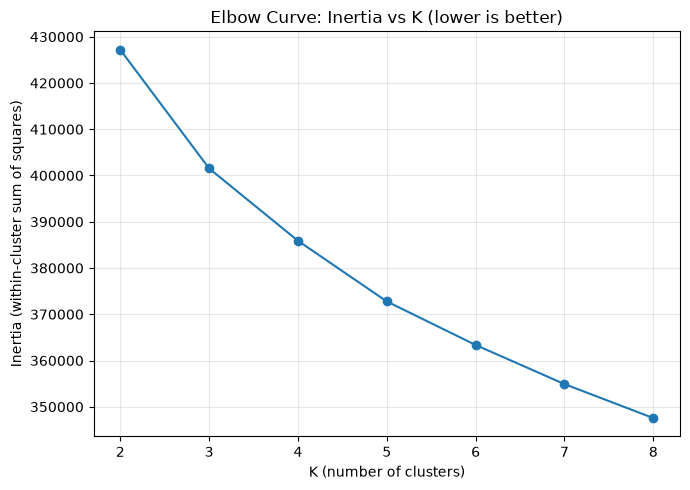

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(baseline_df["K"], baseline_df["inertia"], marker="o")
ax.set_xlabel("K (number of clusters)")
ax.set_ylabel("Inertia (within-cluster sum of squares)")
ax.set_title("Elbow Curve: Inertia vs K (lower is better)")
ax.set_xticks(list(K_RANGE))
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/kmeans_elbow_curve.png", dpi=150)
plt.show()

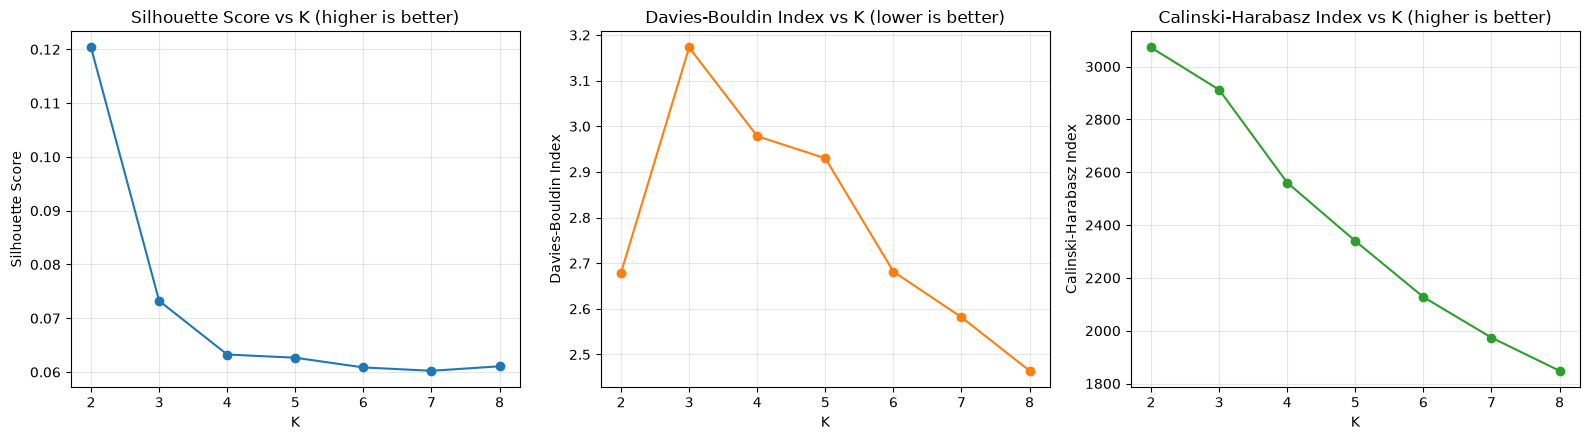

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(baseline_df["K"], baseline_df["silhouette"], marker="o", color="tab:blue")
axes[0].set_title("Silhouette Score vs K (higher is better)")
axes[0].set_xlabel("K")
axes[0].set_ylabel("Silhouette Score")
axes[0].set_xticks(list(K_RANGE))
axes[0].grid(alpha=0.3)

axes[1].plot(baseline_df["K"], baseline_df["davies_bouldin"], marker="o", color="tab:orange")
axes[1].set_title("Davies-Bouldin Index vs K (lower is better)")
axes[1].set_xlabel("K")
axes[1].set_ylabel("Davies-Bouldin Index")
axes[1].set_xticks(list(K_RANGE))
axes[1].grid(alpha=0.3)

axes[2].plot(baseline_df["K"], baseline_df["calinski_harabasz"], marker="o", color="tab:green")
axes[2].set_title("Calinski-Harabasz Index vs K (higher is better)")
axes[2].set_xlabel("K")
axes[2].set_ylabel("Calinski-Harabasz Index")
axes[2].set_xticks(list(K_RANGE))
axes[2].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/kmeans_metrics_vs_k.png", dpi=150)
plt.show()

### Observations — Baseline K-Means (K=2..8)

- **Elbow point**: _TODO — note where inertia's rate of decrease flattens._
- **Silhouette**: _TODO — best K by silhouette score, and how distinct it is from neighboring K values._
- **Davies-Bouldin**: _TODO — best K by DB (lowest), and whether it agrees with silhouette._
- **Calinski-Harabasz**: _TODO — best K by CH (highest), and whether it agrees with the others._
- **Cluster size balance**: _TODO — note any K producing a dominant or tiny cluster (check `min_cluster_pct` / `max_cluster_pct`)._
- **Convergence / runtime**: _TODO — note any K needing unusually many iterations or long runtime._
- **Candidate K for further analysis**: _TODO_

## 3. Hyperparameter Tuning

Select 2-3 candidate K values programmatically from the baseline results, then grid-search `init` and `n_init` for those K values only (full grid search across all K is wasteful once baseline has already narrowed the search).

In [9]:
def find_elbow_k(K_values, inertias):
    """Geometric knee detection: K with max perpendicular distance from the
    chord connecting the first and last (normalized) points on the inertia curve."""
    K_arr = np.array(K_values, dtype=float)
    I_arr = np.array(inertias, dtype=float)
    x = (K_arr - K_arr.min()) / (K_arr.max() - K_arr.min())
    y = (I_arr - I_arr.min()) / (I_arr.max() - I_arr.min())
    x1, y1 = x[0], y[0]
    x2, y2 = x[-1], y[-1]
    num = np.abs((y2 - y1) * x - (x2 - x1) * y + x2 * y1 - y2 * x1)
    den = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
    distances = num / den
    return int(K_arr[np.argmax(distances)])


best_sil_k = int(baseline_df.loc[baseline_df["silhouette"].idxmax(), "K"])
best_db_k = int(baseline_df.loc[baseline_df["davies_bouldin"].idxmin(), "K"])
elbow_k = find_elbow_k(baseline_df["K"].tolist(), baseline_df["inertia"].tolist())

candidate_reasons = {}
for k, reason in [
    (best_sil_k, "best silhouette score"),
    (best_db_k, "best (lowest) Davies-Bouldin index"),
    (elbow_k, "elbow region (max distance-to-chord on the inertia curve)"),
]:
    candidate_reasons.setdefault(k, []).append(reason)

candidate_Ks = list(candidate_reasons.keys())

print("Candidate K values selected for hyperparameter tuning:")
for k in candidate_Ks:
    print(f"  K={k}: " + "; ".join(candidate_reasons[k]))

Candidate K values selected for hyperparameter tuning:
  K=2: best silhouette score
  K=8: best (lowest) Davies-Bouldin index
  K=4: elbow region (max distance-to-chord on the inertia curve)


In [10]:
init_options = ["k-means++", "random"]
n_init_options = [1, 5, 10, 20]
max_iter_options = [300]

tuning_records = []

for k in candidate_Ks:
    for init in init_options:
        for n_init in n_init_options:
            for max_iter in max_iter_options:
                start = time.time()
                model = KMeans(
                    n_clusters=k,
                    init=init,
                    n_init=n_init,
                    max_iter=max_iter,
                    random_state=RANDOM_STATE,
                )
                labels = model.fit_predict(X_dev)
                runtime_sec = time.time() - start

                silhouette = silhouette_score(
                    X_dev, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE
                )
                db = davies_bouldin_score(X_dev, labels)
                ch = calinski_harabasz_score(X_dev, labels)
                sizes, min_pct, max_pct = cluster_size_stats(labels)

                tuning_records.append(
                    {
                        "K": k,
                        "init": init,
                        "n_init": n_init,
                        "max_iter": max_iter,
                        "inertia": model.inertia_,
                        "silhouette": silhouette,
                        "davies_bouldin": db,
                        "calinski_harabasz": ch,
                        "n_iter_": model.n_iter_,
                        "runtime_sec": runtime_sec,
                        "cluster_sizes": sizes,
                        "min_cluster_pct": min_pct,
                        "max_cluster_pct": max_pct,
                    }
                )

tuning_df = pd.DataFrame(tuning_records)
print(f"Completed {len(tuning_df)} tuning runs across {len(candidate_Ks)} candidate K values.")

Completed 24 tuning runs across 3 candidate K values.


In [11]:
# Only re-run with a higher max_iter for configs that actually hit the 300-iteration cap
hit_cap = tuning_df[tuning_df["n_iter_"] >= tuning_df["max_iter"]]

if not hit_cap.empty:
    print(
        f"{len(hit_cap)} run(s) hit max_iter=300 without early convergence; "
        f"re-running these with max_iter=500."
    )
    extra_records = []
    for _, row in hit_cap.iterrows():
        k, init, n_init = int(row["K"]), row["init"], int(row["n_init"])
        max_iter = 500

        start = time.time()
        model = KMeans(
            n_clusters=k,
            init=init,
            n_init=n_init,
            max_iter=max_iter,
            random_state=RANDOM_STATE,
        )
        labels = model.fit_predict(X_dev)
        runtime_sec = time.time() - start

        silhouette = silhouette_score(
            X_dev, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE
        )
        db = davies_bouldin_score(X_dev, labels)
        ch = calinski_harabasz_score(X_dev, labels)
        sizes, min_pct, max_pct = cluster_size_stats(labels)

        extra_records.append(
            {
                "K": k,
                "init": init,
                "n_init": n_init,
                "max_iter": max_iter,
                "inertia": model.inertia_,
                "silhouette": silhouette,
                "davies_bouldin": db,
                "calinski_harabasz": ch,
                "n_iter_": model.n_iter_,
                "runtime_sec": runtime_sec,
                "cluster_sizes": sizes,
                "min_cluster_pct": min_pct,
                "max_cluster_pct": max_pct,
            }
        )

    tuning_df = pd.concat([tuning_df, pd.DataFrame(extra_records)], ignore_index=True)
else:
    print("No run hit max_iter=300 — all configurations converged early; skipping max_iter=500 re-runs.")

1 run(s) hit max_iter=300 without early convergence; re-running these with max_iter=500.


In [12]:
tuning_results_df = tuning_df.copy()
tuning_results_df["cluster_sizes"] = tuning_results_df["cluster_sizes"].apply(json.dumps)
tuning_results_df.to_csv(f"{RESULTS_DIR}/kmeans_tuning_results.csv", index=False)

print(f"Saved tuning results to {RESULTS_DIR}/kmeans_tuning_results.csv")
tuning_df.sort_values(["K", "silhouette"], ascending=[True, False])

Saved tuning results to ../results/kmeans/kmeans_tuning_results.csv


,K,init,n_init,max_iter,inertia,silhouette,davies_bouldin,calinski_harabasz,n_iter_,runtime_sec,cluster_sizes,min_cluster_pct,max_cluster_pct
2,2,k-means++,10,300,427185.982160,0.120339,2.679201,3072.196113,9,0.217420,"{0: 33342, 1: 6658}",16.6450,83.3550
3,2,k-means++,20,300,427185.982160,0.120339,2.679201,3072.196113,9,0.368480,"{0: 33342, 1: 6658}",16.6450,83.3550
5,2,random,5,300,427186.006500,0.120286,2.679356,3072.195713,11,0.090031,"{0: 6659, 1: 33341}",16.6475,83.3525
6,2,random,10,300,427186.006500,0.120286,2.679356,3072.195713,11,0.165920,"{0: 6659, 1: 33341}",16.6475,83.3525
7,2,random,20,300,427186.006500,0.120286,2.679356,3072.195713,11,0.310757,"{0: 6659, 1: 33341}",16.6475,83.3525
1,2,k-means++,5,300,429763.899766,0.064951,3.729048,2813.890447,48,0.119514,"{0: 19825, 1: 20175}",49.5625,50.4375
0,2,k-means++,1,300,430009.858273,0.064406,3.745983,2789.398792,23,0.028958,"{0: 19993, 1: 20007}",49.9825,50.0175
4,2,random,1,300,430009.755435,0.064402,3.745974,2789.412840,32,0.031079,"{0: 20009, 1: 19991}",49.9775,50.0225
21,4,random,5,300,385859.350160,0.063464,2.976195,2561.610963,59,0.174135,"{0: 12699, 1: 10470, 2: 5734, 3: 11097}",14.3350,31.7475
17,4,k-means++,5,300,385884.891010,0.063265,2.978350,2560.544432,45,0.232062,"{0: 5725, 1: 10756, 2: 12811, 3: 10708}",14.3125,32.0275


In [13]:
from IPython.display import display

# Pivot tables (rows=n_init, cols=init) for each candidate K, using the max_iter=300 runs
base_runs = tuning_df[tuning_df["max_iter"] == 300]

for k in candidate_Ks:
    subset = base_runs[base_runs["K"] == k]
    print(f"\n=== K = {k} ===")
    print("Silhouette (higher is better):")
    display(subset.pivot(index="n_init", columns="init", values="silhouette"))
    print("Inertia (lower is better):")
    display(subset.pivot(index="n_init", columns="init", values="inertia"))


=== K = 2 ===
Silhouette (higher is better):


init,k-means++,random
n_init,,
1,0.064406,0.064402
5,0.064951,0.120286
10,0.120339,0.120286
20,0.120339,0.120286


Inertia (lower is better):


init,k-means++,random
n_init,,
1,430009.858273,430009.755435
5,429763.899766,427186.006500
10,427185.982160,427186.006500
20,427185.982160,427186.006500



=== K = 8 ===
Silhouette (higher is better):


...

init,k-means++,random
n_init,,
1,347753.806928,347521.750913
5,347555.405766,347319.001221
10,347555.405766,347319.001221
20,347368.863183,347283.848151



=== K = 4 ===
Silhouette (higher is better):


init,k-means++,random
n_init,,
1,0.062928,0.062883
5,0.063265,0.063464
10,0.063265,0.062678
20,0.062702,0.063154


Inertia (lower is better):


init,k-means++,random
n_init,,
1,385933.250933,385914.835353
5,385884.891010,385859.350160
10,385884.891010,385803.719401
20,385805.674344,385521.752854


**Why `n_init` and `init='k-means++'` matter:**

K-Means is sensitive to its starting centroids — it only guarantees convergence to a *local* optimum, and a bad initialization can get stuck in a poor one (higher inertia, worse-separated clusters). `n_init` runs the whole algorithm multiple times with different random starting points and keeps the best result (lowest inertia), which lowers the risk of reporting a bad local minimum — at the cost of proportionally more compute.

`init='k-means++'` improves on purely random starting centroids by spreading them out: each new centroid is chosen with probability proportional to its squared distance from the centroids already chosen. This gives a smarter starting point than `init='random'`, usually converges faster (fewer iterations) and more reliably to a good local optimum, which is why it is scikit-learn's default and why it is expected to need a lower `n_init` than `'random'` to reach comparable quality.

## 4. Stability Analysis

For each candidate K, take its best tuned configuration from Section 3 and check how stable the resulting clustering is in two independent ways:
1. **Seed stability** — refit with 10 different random seeds and compare the resulting labelings pairwise with Adjusted Rand Index (ARI).
2. **Subsample stability** — fit on 5 random 80% subsamples of the development set, then use each fitted model to predict labels for the *full* development set and compare against a reference labeling with ARI.

In [14]:
best_params_by_k = {}
for k in candidate_Ks:
    subset = tuning_df[tuning_df["K"] == k]
    best_row = subset.loc[subset["silhouette"].idxmax()]
    best_params_by_k[k] = {
        "init": best_row["init"],
        "n_init": int(best_row["n_init"]),
        "max_iter": int(best_row["max_iter"]),
    }
    print(
        f"K={k}: best tuned params -> {best_params_by_k[k]} "
        f"(silhouette={best_row['silhouette']:.4f})"
    )

K=2: best tuned params -> {'init': 'k-means++', 'n_init': 10, 'max_iter': 300} (silhouette=0.1203)
K=8: best tuned params -> {'init': 'k-means++', 'n_init': 5, 'max_iter': 300} (silhouette=0.0611)
K=4: best tuned params -> {'init': 'random', 'n_init': 5, 'max_iter': 300} (silhouette=0.0635)


In [15]:
SEEDS = list(range(10))

seed_metric_records = []
seed_labels_by_k = {}

for k in candidate_Ks:
    params = best_params_by_k[k]
    label_sets = []
    for seed in SEEDS:
        model = KMeans(
            n_clusters=k,
            init=params["init"],
            n_init=params["n_init"],
            max_iter=params["max_iter"],
            random_state=seed,
        )
        labels = model.fit_predict(X_dev)
        label_sets.append(labels)

        # Fixed random_state here so every seed's silhouette is computed on the
        # same sampled points, keeping the comparison across seeds apples-to-apples
        silhouette = silhouette_score(
            X_dev, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE
        )
        db = davies_bouldin_score(X_dev, labels)
        ch = calinski_harabasz_score(X_dev, labels)

        seed_metric_records.append(
            {
                "K": k,
                "seed": seed,
                "inertia": model.inertia_,
                "silhouette": silhouette,
                "davies_bouldin": db,
                "calinski_harabasz": ch,
            }
        )

    seed_labels_by_k[k] = label_sets

seed_metrics_df = pd.DataFrame(seed_metric_records)
print(f"Fitted {len(seed_metrics_df)} models across {len(candidate_Ks)} K values x {len(SEEDS)} seeds.")

Fitted 30 models across 3 K values x 10 seeds.


In [16]:
seed_summary_df = seed_metrics_df.groupby("K").agg(
    silhouette_mean=("silhouette", "mean"),
    silhouette_std=("silhouette", "std"),
    davies_bouldin_mean=("davies_bouldin", "mean"),
    davies_bouldin_std=("davies_bouldin", "std"),
    calinski_harabasz_mean=("calinski_harabasz", "mean"),
    calinski_harabasz_std=("calinski_harabasz", "std"),
    inertia_mean=("inertia", "mean"),
    inertia_std=("inertia", "std"),
).reset_index()
seed_summary_df

,K,silhouette_mean,silhouette_std,davies_bouldin_mean,davies_bouldin_std,calinski_harabasz_mean,calinski_harabasz_std,inertia_mean,inertia_std
0,2,0.109292,0.023290,2.889899,0.444427,3019.414848,111.30447,427712.776398,1110.891905
1,4,0.063347,0.000515,2.976855,0.007333,2565.153271,5.62041,385773.154955,136.496053
2,8,0.060377,0.000625,2.464847,0.013159,1851.355729,3.12084,347416.882124,143.409838


In [17]:
from itertools import combinations

pairwise_ari_records = []
for k in candidate_Ks:
    label_sets = seed_labels_by_k[k]
    aris = [adjusted_rand_score(a, b) for a, b in combinations(label_sets, 2)]
    pairwise_ari_records.append(
        {
            "K": k,
            "pairwise_ari_mean": float(np.mean(aris)),
            "pairwise_ari_min": float(np.min(aris)),
            "pairwise_ari_max": float(np.max(aris)),
            "n_pairs": len(aris),
        }
    )

pairwise_ari_df = pd.DataFrame(pairwise_ari_records)
pairwise_ari_df

,K,pairwise_ari_mean,pairwise_ari_min,pairwise_ari_max,n_pairs
0,2,0.622077,-0.000020,1.000000,45
1,8,0.263167,0.178708,0.621586,45
2,4,0.261562,0.145315,0.929015,45


In [18]:
# Reference labeling per K: best tuned params fit on the full dev set with RANDOM_STATE
reference_labels = {}
for k in candidate_Ks:
    params = best_params_by_k[k]
    model = KMeans(
        n_clusters=k,
        init=params["init"],
        n_init=params["n_init"],
        max_iter=params["max_iter"],
        random_state=RANDOM_STATE,
    )
    reference_labels[k] = model.fit_predict(X_dev)

In [19]:
SUBSAMPLE_FRAC = 0.8
N_SUBSAMPLES = 5
n_dev = X_dev.shape[0]

subsample_ari_records = []
for k in candidate_Ks:
    params = best_params_by_k[k]
    ref_labels = reference_labels[k]

    for i in range(N_SUBSAMPLES):
        rng = np.random.RandomState(RANDOM_STATE + i)
        subsample_idx = rng.choice(n_dev, size=int(n_dev * SUBSAMPLE_FRAC), replace=False)
        X_sub = X_dev.iloc[subsample_idx]

        sub_model = KMeans(
            n_clusters=k,
            init=params["init"],
            n_init=params["n_init"],
            max_iter=params["max_iter"],
            random_state=RANDOM_STATE + i,
        )
        sub_model.fit(X_sub)

        # Predict labels for the FULL dev set from the subsample-fitted model,
        # then compare against the reference labeling with ARI
        full_labels_from_sub = sub_model.predict(X_dev)
        ari = adjusted_rand_score(ref_labels, full_labels_from_sub)

        subsample_ari_records.append({"K": k, "subsample_idx": i, "ari_vs_reference": ari})

subsample_ari_df = pd.DataFrame(subsample_ari_records)
subsample_ari_df

,K,subsample_idx,ari_vs_reference
0,2,0,0.994396
1,2,1,0.000109
2,2,2,0.996140
3,2,3,0.997259
4,2,4,0.997259
5,8,0,0.319238
6,8,1,0.379336
7,8,2,0.246646
8,8,3,0.371645
9,8,4,0.225827


In [20]:
subsample_summary_df = subsample_ari_df.groupby("K").agg(
    subsample_ari_mean=("ari_vs_reference", "mean"),
    subsample_ari_min=("ari_vs_reference", "min"),
).reset_index()

stability_df = (
    seed_summary_df
    .merge(pairwise_ari_df, on="K")
    .merge(subsample_summary_df, on="K")
)
stability_df = stability_df[
    [
        "K",
        "silhouette_mean", "silhouette_std",
        "davies_bouldin_mean", "davies_bouldin_std",
        "calinski_harabasz_mean", "calinski_harabasz_std",
        "inertia_mean", "inertia_std",
        "pairwise_ari_mean", "pairwise_ari_min", "pairwise_ari_max", "n_pairs",
        "subsample_ari_mean", "subsample_ari_min",
    ]
]

stability_df.to_csv(f"{RESULTS_DIR}/kmeans_stability_results.csv", index=False)
print(f"Saved stability results to {RESULTS_DIR}/kmeans_stability_results.csv")
stability_df

Saved stability results to ../results/kmeans/kmeans_stability_results.csv


,K,silhouette_mean,silhouette_std,davies_bouldin_mean,davies_bouldin_std,calinski_harabasz_mean,calinski_harabasz_std,inertia_mean,inertia_std,pairwise_ari_mean,pairwise_ari_min,pairwise_ari_max,n_pairs,subsample_ari_mean,subsample_ari_min
0,2,0.109292,0.023290,2.889899,0.444427,3019.414848,111.30447,427712.776398,1110.891905,0.622077,-0.000020,1.000000,45,0.797032,0.000109
1,4,0.063347,0.000515,2.976855,0.007333,2565.153271,5.62041,385773.154955,136.496053,0.261562,0.145315,0.929015,45,0.243637,0.144034
2,8,0.060377,0.000625,2.464847,0.013159,1851.355729,3.12084,347416.882124,143.409838,0.263167,0.178708,0.621586,45,0.308538,0.225827


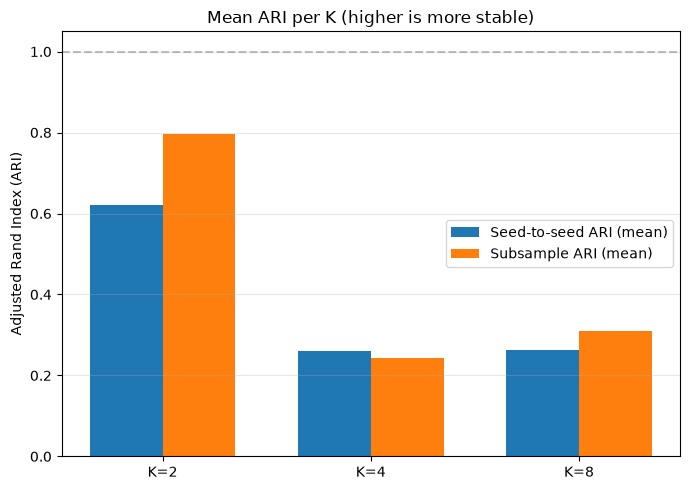

In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(stability_df))
width = 0.35

ax.bar(x - width / 2, stability_df["pairwise_ari_mean"], width, label="Seed-to-seed ARI (mean)", color="tab:blue")
ax.bar(x + width / 2, stability_df["subsample_ari_mean"], width, label="Subsample ARI (mean)", color="tab:orange")

ax.set_xticks(x)
ax.set_xticklabels([f"K={k}" for k in stability_df["K"]])
ax.set_ylabel("Adjusted Rand Index (ARI)")
ax.set_title("Mean ARI per K (higher is more stable)")
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5)
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/kmeans_stability_ari.png", dpi=150)
plt.show()

**Interpreting ARI here:** the Adjusted Rand Index measures agreement between two label assignments, correcting for chance, on a scale where 1.0 = identical clustering and 0.0 = agreement no better than random labeling. **ARI ≈ 1 means the model finds essentially the same clusters every time** — whether re-run from a different random seed (seed stability) or fit on a different 80% slice of customers (subsample stability) — which is what we want from a clustering we intend to act on. A low mean ARI, or a wide gap between `pairwise_ari_mean` and `pairwise_ari_min`, flags a K whose segmentation is sensitive to randomness or sampling and should be treated with more caution when used for business decisions.

## 5. Best K-Means Configuration

Combine the tuned metrics and stability results into one summary table per candidate K, apply explicit rejection/ranking rules to pick a single configuration, and refit it on the full development set.

**This is not the group's final chosen model** — it is the best-performing K-Means configuration among the candidates evaluated here, produced so `06_Model_Comparison.ipynb` has a representative, well-tuned K-Means result to compare against GMM, Fuzzy C-Means, and Agglomerative Clustering.

In [22]:
summary_rows = []
for k in candidate_Ks:
    stab_row = stability_df[stability_df["K"] == k].iloc[0]
    params = best_params_by_k[k]

    # Cluster-size balance from the reference labeling (best params, fixed RANDOM_STATE)
    _, min_pct, max_pct = cluster_size_stats(reference_labels[k])

    tuning_row = tuning_df[
        (tuning_df["K"] == k)
        & (tuning_df["init"] == params["init"])
        & (tuning_df["n_init"] == params["n_init"])
        & (tuning_df["max_iter"] == params["max_iter"])
    ].iloc[0]

    # Combine both stability checks into one "mean ARI" used for the stability gate
    mean_ari = (stab_row["pairwise_ari_mean"] + stab_row["subsample_ari_mean"]) / 2

    summary_rows.append(
        {
            "K": k,
            "init": params["init"],
            "n_init": params["n_init"],
            "max_iter": params["max_iter"],
            "silhouette": stab_row["silhouette_mean"],
            "davies_bouldin": stab_row["davies_bouldin_mean"],
            "calinski_harabasz": stab_row["calinski_harabasz_mean"],
            "min_cluster_pct": min_pct,
            "max_cluster_pct": max_pct,
            "pairwise_ari_mean": stab_row["pairwise_ari_mean"],
            "subsample_ari_mean": stab_row["subsample_ari_mean"],
            "mean_ari": mean_ari,
            "runtime_sec": tuning_row["runtime_sec"],
        }
    )

summary_df = pd.DataFrame(summary_rows)
summary_df

,K,init,n_init,max_iter,silhouette,davies_bouldin,calinski_harabasz,min_cluster_pct,max_cluster_pct,pairwise_ari_mean,subsample_ari_mean,mean_ari,runtime_sec
0,2,k-means++,10,300,0.109292,2.889899,3019.414848,16.645,83.3550,0.622077,0.797032,0.709555,0.217420
1,8,k-means++,5,300,0.060377,2.464847,1851.355729,12.345,12.7500,0.263167,0.308538,0.285853,0.509315
2,4,random,5,300,0.063347,2.976855,2565.153271,14.335,31.7475,0.261562,0.243637,0.252599,0.174135


In [23]:
MIN_CLUSTER_PCT_THRESHOLD = 5.0
MIN_ARI_THRESHOLD = 0.9

print("=== K-Means Final Selection ===\n")
print(f"Rule 1 - reject K with any cluster < {MIN_CLUSTER_PCT_THRESHOLD}% of customers (degenerate)")
print(f"Rule 2 - reject K with mean ARI < {MIN_ARI_THRESHOLD} (unstable)\n")

rejected = {}
remaining = []

for _, row in summary_df.iterrows():
    k = int(row["K"])
    if row["min_cluster_pct"] < MIN_CLUSTER_PCT_THRESHOLD:
        rejected[k] = (
            f"degenerate cluster: min_cluster_pct={row['min_cluster_pct']:.2f}% "
            f"< {MIN_CLUSTER_PCT_THRESHOLD}%"
        )
    elif row["mean_ari"] < MIN_ARI_THRESHOLD:
        rejected[k] = f"unstable: mean_ari={row['mean_ari']:.4f} < {MIN_ARI_THRESHOLD}"
    else:
        remaining.append(k)

for k in candidate_Ks:
    if k in rejected:
        print(f"  K={k}: REJECTED \u2014 {rejected[k]}")
    else:
        print(f"  K={k}: passes rules 1 & 2")

if not remaining:
    print(
        "\nNo candidate K survived Rule 1 (degenerate) and Rule 2 (mean ARI >= "
        f"{MIN_ARI_THRESHOLD}). None of the evaluated K-Means configurations produce a "
        "stable segmentation of this feature set at the required bar.\n"
        "This is treated as a genuine negative result, not a pipeline failure: "
        "best_k is set to None, the final refit and holdout evaluation below are "
        "skipped, and 'K-Means found no stable configuration' becomes the reportable "
        "conclusion for 06_Model_Comparison.ipynb."
    )

=== K-Means Final Selection ===

Rule 1 - reject K with any cluster < 5.0% of customers (degenerate)
Rule 2 - reject K with mean ARI < 0.9 (unstable)

  K=2: REJECTED — unstable: mean_ari=0.7096 < 0.9
  K=8: REJECTED — unstable: mean_ari=0.2859 < 0.9
  K=4: REJECTED — unstable: mean_ari=0.2526 < 0.9

No candidate K survived Rule 1 (degenerate) and Rule 2 (mean ARI >= 0.9). None of the evaluated K-Means configurations produce a stable segmentation of this feature set at the required bar.
This is treated as a genuine negative result, not a pipeline failure: best_k is set to None, the final refit and holdout evaluation below are skipped, and 'K-Means found no stable configuration' becomes the reportable conclusion for 06_Model_Comparison.ipynb.


In [24]:
if remaining:
    ranking_df = summary_df[summary_df["K"].isin(remaining)].copy()
    ranking_df["rank_silhouette"] = ranking_df["silhouette"].rank(ascending=False)
    ranking_df["rank_db"] = ranking_df["davies_bouldin"].rank(ascending=True)
    ranking_df["rank_ch"] = ranking_df["calinski_harabasz"].rank(ascending=False)
    ranking_df["avg_rank"] = ranking_df[["rank_silhouette", "rank_db", "rank_ch"]].mean(axis=1)
    ranking_df = ranking_df.sort_values("avg_rank")

    print("Rule 3 - rank surviving candidates by silhouette, Davies-Bouldin, and Calinski-Harabasz")
    print("(average rank across the three; lower avg_rank is better)\n")
    display(ranking_df[["K", "silhouette", "davies_bouldin", "calinski_harabasz", "avg_rank"]])

    best_k = int(ranking_df.iloc[0]["K"])
    STABLE_SELECTION = True

    print(f"\nElbow region (support only, not a hard filter): K={elbow_k}")
    if best_k != elbow_k:
        print(
            f"Note: selected K={best_k} differs from the elbow-region K={elbow_k}; "
            f"the elbow is treated as supporting context, not a veto."
        )
    else:
        print(f"Selected K={best_k} also matches the elbow region, reinforcing the choice.")
else:
    ranking_df = None
    STABLE_SELECTION = False
    best_k = int(summary_df.loc[summary_df["mean_ari"].idxmax(), "K"])
    print("Skipping Rule 3 ranking — no candidate K survived Rules 1 & 2.")
    print(
        f"\nBest-effort fallback (project decision): K={best_k} is the closest candidate to the "
        f"stability bar (mean ARI={summary_df['mean_ari'].max():.4f}, still below {MIN_ARI_THRESHOLD}). "
        "It is refit below and carried through Sections 6-8 as this notebook's final model for "
        "cross-model comparison, but it is explicitly NOT a validated stable configuration."
    )

Skipping Rule 3 ranking — no candidate K survived Rules 1 & 2.

Best-effort fallback (project decision): K=2 is the closest candidate to the stability bar (mean ARI=0.7096, still below 0.9). It is refit below and carried through Sections 6-8 as this notebook's final model for cross-model comparison, but it is explicitly NOT a validated stable configuration.


In [25]:
if best_k is not None:
    final_params = best_params_by_k[best_k]

    print("Chosen K-Means configuration for comparison in 06_Model_Comparison:")
    print(f"  K           = {best_k}")
    print(f"  init        = {final_params['init']}")
    print(f"  n_init      = {final_params['n_init']}")
    print(f"  max_iter    = {final_params['max_iter']}")
    print(f"  random_state = {RANDOM_STATE}")
else:
    final_params = None
    print(
        "No K-Means configuration met the stability bar (mean ARI >= "
        f"{MIN_ARI_THRESHOLD}) \u2014 there is no 'best' configuration to report here."
    )

Chosen K-Means configuration for comparison in 06_Model_Comparison:
  K           = 2
  init        = k-means++
  n_init      = 10
  max_iter    = 300
  random_state = 42


In [26]:
if best_k is not None:
    start = time.time()
    final_kmeans_model = KMeans(
        n_clusters=best_k,
        init=final_params["init"],
        n_init=final_params["n_init"],
        max_iter=final_params["max_iter"],
        random_state=RANDOM_STATE,
    )
    final_dev_labels = final_kmeans_model.fit_predict(X_dev)
    final_runtime_sec = time.time() - start

    final_silhouette = silhouette_score(
        X_dev, final_dev_labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE
    )
    final_db = davies_bouldin_score(X_dev, final_dev_labels)
    final_ch = calinski_harabasz_score(X_dev, final_dev_labels)
    final_sizes, final_min_pct, final_max_pct = cluster_size_stats(final_dev_labels)

    print("Refit final K-Means model on the full development set:")
    print(
        f"  inertia={final_kmeans_model.inertia_:,.1f} silhouette={final_silhouette:.4f} "
        f"db={final_db:.4f} ch={final_ch:,.1f} runtime={final_runtime_sec:.2f}s"
    )
    print(f"  cluster sizes: {final_sizes}")
    print(f"  min_cluster_pct={final_min_pct:.2f}% max_cluster_pct={final_max_pct:.2f}%")
else:
    final_kmeans_model = None
    final_dev_labels = None
    final_silhouette = final_db = final_ch = None
    final_sizes = {}
    final_min_pct = final_max_pct = None
    print("Skipping final refit \u2014 no stable K-Means configuration was selected above.")

Refit final K-Means model on the full development set:
  inertia=427,186.0 silhouette=0.1203 db=2.6792 ch=3,072.2 runtime=0.20s
  cluster sizes: {0: 33342, 1: 6658}
  min_cluster_pct=16.64% max_cluster_pct=83.36%


### Justification — Best K-Means Configuration

**Outcome: no K-Means configuration met the stability bar.**

All three candidate K values failed Rule 2 (mean ARI ≥ 0.9):

| K | mean ARI | pairwise (seed) ARI mean | subsample ARI mean |
|---|---|---|---|
| 2 | 0.71 | 0.62 (min ≈ 0.0) | 0.80 (min ≈ 0.0001) |
| 4 | 0.25 | 0.26 | 0.24 |
| 8 | 0.29 | 0.26 | 0.31 |

K=2 came closest, but even it has at least one seed pair and one subsample run landing near ARI≈0 — meaning a second, roughly-equally-good 2-way split of the customers also exists.

For K=4 and K=8, inertia and silhouette barely move across the 10 seeds (std < 0.05% of the mean) — K-Means reliably finds a solution of the *same quality* every time, but the *specific partition* it lands on differs substantially between seeds. This is the signature of multiple, near-equally-good partitions rather than one well-defined cluster structure, consistent with the uniformly low silhouette scores (0.06-0.12) observed across K=2..8 in Section 2.

**Conclusion for `06_Model_Comparison.ipynb`:** K-Means does not produce a stable segmentation of this customer base at any evaluated K. This is a legitimate negative result, not a tuning failure — the behavioral features used here don't appear to contain well-separated, hard clusters, which may favor soft/probabilistic clustering (GMM, Fuzzy C-Means) when comparing across models.

**Decision — best-effort final model:** despite failing Rule 2, the group decided to still produce a final K-Means model for cross-model comparison and artifact purposes, using **K=2** — the closest-to-stable candidate (mean ARI=0.71, highest silhouette among the three). It is refit on the full development set in the cell below and carried through Sections 6–8 (holdout evaluation, cluster profiling, model/artifact saving). This is explicitly **not** a validated stable configuration — a different random seed can produce a meaningfully different 2-way split (ARI as low as ≈0 was observed against at least one seed and one subsample in Section 4) — so its holdout metrics and cluster profile should be read as illustrative, not as evidence of a reliable customer segmentation.

## 6. Holdout Evaluation

Check whether the chosen clustering generalises to customers it never saw during fitting. We only call `.predict()` on the holdout set with the already-fitted `final_kmeans_model` — no refitting, no re-scaling.

In [27]:
if final_kmeans_model is not None:
    # Predict only \u2014 the holdout set is never used to fit or re-fit the model
    holdout_labels = final_kmeans_model.predict(X_hold)

    hold_silhouette = silhouette_score(
        X_hold,
        holdout_labels,
        sample_size=min(SIL_SAMPLE, X_hold.shape[0]),
        random_state=RANDOM_STATE,
    )
    hold_db = davies_bouldin_score(X_hold, holdout_labels)
    hold_ch = calinski_harabasz_score(X_hold, holdout_labels)
    hold_sizes, hold_min_pct, hold_max_pct = cluster_size_stats(holdout_labels)

    print("Holdout evaluation (predict only, no refitting):")
    print(
        f"  silhouette={hold_silhouette:.4f} db={hold_db:.4f} ch={hold_ch:,.1f} "
        f"min_cluster_pct={hold_min_pct:.2f}% max_cluster_pct={hold_max_pct:.2f}%"
    )
    print(f"  cluster sizes: {hold_sizes}")
else:
    holdout_labels = None
    hold_silhouette = hold_db = hold_ch = None
    hold_sizes = {}
    hold_min_pct = hold_max_pct = None
    print("Skipping holdout evaluation \u2014 no stable K-Means configuration was selected in Section 5.")

Holdout evaluation (predict only, no refitting):
  silhouette=0.1246 db=2.6604 ch=795.5 min_cluster_pct=16.96% max_cluster_pct=83.04%
  cluster sizes: {0: 8304, 1: 1696}


In [28]:
if final_kmeans_model is not None:
    comparison_df = pd.DataFrame(
        {
            "metric": [
                "silhouette",
                "davies_bouldin",
                "calinski_harabasz",
                "min_cluster_pct",
                "max_cluster_pct",
                "n_customers",
            ],
            "development": [
                final_silhouette,
                final_db,
                final_ch,
                final_min_pct,
                final_max_pct,
                X_dev.shape[0],
            ],
            "holdout": [
                hold_silhouette,
                hold_db,
                hold_ch,
                hold_min_pct,
                hold_max_pct,
                X_hold.shape[0],
            ],
        }
    )
    comparison_df["abs_diff"] = (comparison_df["development"] - comparison_df["holdout"]).abs()
else:
    comparison_df = None
    print("Skipping dev/holdout comparison \u2014 no final model available.")
comparison_df

,metric,development,holdout,abs_diff
0,silhouette,0.120339,0.124554,0.004215
1,davies_bouldin,2.679201,2.660369,0.018831
2,calinski_harabasz,3072.196113,795.538247,2276.657866
3,min_cluster_pct,16.645000,16.960000,0.315000
4,max_cluster_pct,83.355000,83.040000,0.315000
5,n_customers,40000.000000,10000.000000,30000.000000


In [29]:
if final_kmeans_model is not None:
    # Per-cluster size % \u2014 development vs holdout
    n_dev_total = X_dev.shape[0]
    n_hold_total = X_hold.shape[0]

    cluster_pct_df = pd.DataFrame({"cluster": sorted(set(final_sizes) | set(hold_sizes))})
    cluster_pct_df["dev_pct"] = cluster_pct_df["cluster"].map(
        lambda c: final_sizes.get(c, 0) / n_dev_total * 100
    )
    cluster_pct_df["holdout_pct"] = cluster_pct_df["cluster"].map(
        lambda c: hold_sizes.get(c, 0) / n_hold_total * 100
    )
    cluster_pct_df["pct_point_diff"] = (
        cluster_pct_df["dev_pct"] - cluster_pct_df["holdout_pct"]
    ).abs()
else:
    cluster_pct_df = None
    print("Skipping per-cluster size comparison \u2014 no final model available.")
cluster_pct_df

,cluster,dev_pct,holdout_pct,pct_point_diff
0,0,83.355,83.04,0.315
1,1,16.645,16.96,0.315


**Interpreting this comparison:** the holdout set was never seen during fitting (or during K/hyperparameter selection) — it only goes through `.predict()`. If the development and holdout values above are close for silhouette, Davies-Bouldin, Calinski-Harabasz, and per-cluster size %, that means **the segments the model learned on the development set generalise to unseen customers**, rather than being an artifact of the specific rows it was fit on. Large gaps (e.g. a cluster that is a reasonable size in development but tiny or empty in holdout) would instead suggest the clustering overfit to development-set-specific structure and should be treated with caution before being used operationally.

## 7. Cluster Profiles

Profile the final model's centroids in the already-scaled feature space, and identify each cluster's most distinguishing features. We deliberately do **not** join `customer_lifetime_value_usd` or `churn_risk_score` here \u2014 that business-level profiling happens separately at the group level once every member's clustering is finalized.

This section only has something to show if Section 5 selected a stable `final_kmeans_model`; given the current result (no K met the ARI stability bar), it will print a skip message instead.

In [30]:
if final_kmeans_model is not None:
    centroids_df = pd.DataFrame(
        final_kmeans_model.cluster_centers_,
        columns=X_dev.columns,
        index=[f"Cluster {i}" for i in range(final_kmeans_model.n_clusters)],
    )

    print(f"Final model: K={best_k}, scaled feature-space centroids")
    print(f"Cluster sizes: {final_sizes}\n")
    display(centroids_df.round(3))
else:
    centroids_df = None
    print("Skipping cluster profiling \u2014 Section 5 found no stable K-Means configuration to profile.")

Final model: K=2, scaled feature-space centroids
Cluster sizes: {0: 33342, 1: 6658}



,tenure_months,total_purchases,avg_order_value_usd,days_since_last_purchase,return_count,complaint_count,satisfaction_score,email_open_rate,click_through_rate,conversion_rate,shopping_channel_In-Store,shopping_channel_Marketplace,shopping_channel_Mobile App,shopping_channel_Online,device_used_Desktop,device_used_Mobile,device_used_Multiple,device_used_Tablet
Cluster 0,-0.002,0.002,0.004,-0.405,0.000,-0.001,-0.001,-0.004,-0.001,0.002,0.251,0.244,0.252,0.252,0.254,0.245,0.250,0.250
Cluster 1,0.012,-0.010,-0.021,2.026,-0.001,0.007,0.006,0.020,0.007,-0.009,0.254,0.252,0.244,0.250,0.254,0.251,0.244,0.251


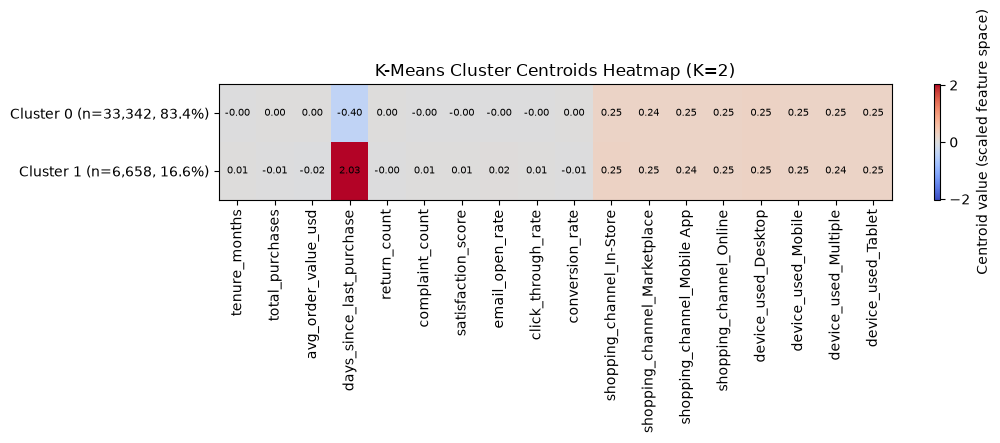

In [31]:
if final_kmeans_model is not None:
    fig, ax = plt.subplots(
        figsize=(max(10, centroids_df.shape[1] * 0.6), max(4, centroids_df.shape[0] * 0.9))
    )
    vmax = centroids_df.abs().values.max()
    im = ax.imshow(centroids_df.values, cmap="coolwarm", vmin=-vmax, vmax=vmax, aspect="auto")

    ax.set_xticks(range(centroids_df.shape[1]))
    ax.set_xticklabels(centroids_df.columns, rotation=90, ha="center")

    total_customers = sum(final_sizes.values())
    y_labels = [
        f"{idx} (n={final_sizes[i]:,}, {final_sizes[i] / total_customers * 100:.1f}%)"
        for i, idx in enumerate(centroids_df.index)
    ]
    ax.set_yticks(range(centroids_df.shape[0]))
    ax.set_yticklabels(y_labels)

    for i in range(centroids_df.shape[0]):
        for j in range(centroids_df.shape[1]):
            ax.text(
                j, i, f"{centroids_df.values[i, j]:.2f}",
                ha="center", va="center", fontsize=7,
            )

    fig.colorbar(im, ax=ax, label="Centroid value (scaled feature space)")
    ax.set_title(f"K-Means Cluster Centroids Heatmap (K={best_k})")
    fig.tight_layout()
    fig.savefig(f"{FIGURES_DIR}/kmeans_cluster_centroids_heatmap.png", dpi=150)
    plt.show()
else:
    print("Skipping heatmap \u2014 no final model to profile.")

In [32]:
N_TOP_FEATURES = 3

if final_kmeans_model is not None:
    print(f"Top {N_TOP_FEATURES} distinguishing features per cluster (by |centroid value|):\n")
    for idx in centroids_df.index:
        row = centroids_df.loc[idx]
        top_features = row.abs().sort_values(ascending=False).head(N_TOP_FEATURES)
        print(f"{idx}:")
        for feat in top_features.index:
            print(f"  {feat}: {row[feat]:+.3f}")
        print()
else:
    print("Skipping \u2014 no final model to profile.")

Top 3 distinguishing features per cluster (by |centroid value|):

Cluster 0:
  days_since_last_purchase: -0.405
  device_used_Desktop: +0.254
  shopping_channel_Mobile App: +0.252

Cluster 1:
  days_since_last_purchase: +2.026
  device_used_Desktop: +0.254
  shopping_channel_In-Store: +0.254



**Note on interpreting these centroids:** values are in the already-scaled feature space produced by `01_EDA_Preprocessing.ipynb`, not original business units \u2014 e.g. a `tenure_months` centroid of `-0.8` means 0.8 standard deviations below the development-set mean, not \u2212 0.8 months. CLV and churn are intentionally excluded from this profiling step; they are joined in at the group level later, once every member's clustering is finalized, so this notebook's conclusions about K-Means stay independent of those outcome variables.

## 8. Save Artifacts

Persist the final model, cluster assignments, and a structured summary record for `06_Model_Comparison.ipynb`. Section 5 found that no K met the strict stability bar (mean ARI ≥ 0.9); per the group's decision, the closest-to-stable candidate (K=2) is still refit and saved here as a best-effort final model — clearly flagged as unstable rather than validated — alongside `kmeans_summary.json`, which documents the full rule-based outcome and everything that was tried (baseline, tuning, stability analysis).

In [33]:
MODELS_DIR = "../models"
os.makedirs(MODELS_DIR, exist_ok=True)

if final_kmeans_model is not None:
    model_path = f"{MODELS_DIR}/kmeans_final_model.pkl"
    joblib.dump(final_kmeans_model, model_path)
    print(f"Saved final K-Means model to {model_path}")
    if not STABLE_SELECTION:
        print(
            "NOTE: this configuration did not meet the stability bar (mean ARI >= "
            f"{MIN_ARI_THRESHOLD}) in Section 5 — saved as a best-effort model for "
            "cross-model comparison, not a validated stable segmentation."
        )
else:
    model_path = None
    print("Skipping model save — no stable K-Means configuration was selected in Section 5.")

Saved final K-Means model to ../models/kmeans_final_model.pkl
NOTE: this configuration did not meet the stability bar (mean ARI >= 0.9) in Section 5 — saved as a best-effort model for cross-model comparison, not a validated stable segmentation.


In [34]:
if final_kmeans_model is not None:
    dev_assignments_df = pd.DataFrame(
        {"customer_id": dev_customer_id, "cluster": final_dev_labels}
    )
    dev_assignments_path = f"{RESULTS_DIR}/kmeans_dev_assignments.csv"
    dev_assignments_df.to_csv(dev_assignments_path, index=False)
    print(f"Saved {len(dev_assignments_df)} development-set assignments to {dev_assignments_path}")
else:
    dev_assignments_df = None
    dev_assignments_path = None
    print("Skipping development-set assignments \u2014 no final model available.")

Saved 40000 development-set assignments to ../results/kmeans/kmeans_dev_assignments.csv


In [35]:
if final_kmeans_model is not None:
    holdout_assignments_df = pd.DataFrame(
        {"customer_id": holdout_customer_id, "cluster": holdout_labels}
    )
    holdout_assignments_path = f"{RESULTS_DIR}/kmeans_holdout_assignments.csv"
    holdout_assignments_df.to_csv(holdout_assignments_path, index=False)
    print(f"Saved {len(holdout_assignments_df)} holdout-set assignments to {holdout_assignments_path}")
else:
    holdout_assignments_df = None
    holdout_assignments_path = None
    print("Skipping holdout-set assignments \u2014 no final model available.")

Saved 10000 holdout-set assignments to ../results/kmeans/kmeans_holdout_assignments.csv


In [36]:
def _to_jsonable(obj):
    """Recursively convert numpy scalars/arrays and non-str dict keys to JSON-safe types."""
    if isinstance(obj, dict):
        return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


summary_record = {
    "algorithm": "K-Means",
    "rationale": (
        "Hard-clustering benchmark for customer segmentation: partitions customers into "
        "K disjoint groups by minimizing within-cluster variance over standardized "
        "behavioral/engagement features. customer_id, customer_lifetime_value_usd, and "
        "churn_risk_score are excluded from the feature matrix (see Section 1)."
    ),
    "baseline": {
        "params": {"init": "k-means++", "n_init": 10, "max_iter": 300, "random_state": RANDOM_STATE},
        "k_range": list(K_RANGE),
        "metrics_by_k": baseline_df.drop(columns=["cluster_sizes"]).to_dict(orient="records"),
    },
    "experiments_tested": {
        "candidate_K_selection": candidate_reasons,
        "hyperparameter_grid": {
            "init": init_options,
            "n_init": n_init_options,
            "max_iter_primary": max_iter_options,
            "max_iter_fallback_if_capped": 500,
            "n_tuning_runs": len(tuning_df),
        },
        "stability_analysis": {
            "seed_stability": {"n_seeds": len(SEEDS), "seeds": SEEDS},
            "subsample_stability": {
                "n_subsamples": N_SUBSAMPLES,
                "subsample_frac": SUBSAMPLE_FRAC,
            },
        },
    },
    "optimization_changes": {
        k_: {
            "baseline_params": {"init": "k-means++", "n_init": 10, "max_iter": 300},
            "tuned_params": best_params_by_k[k_],
        }
        for k_ in candidate_Ks
    },
    "selection_rules": {
        "rule_1_min_cluster_pct": MIN_CLUSTER_PCT_THRESHOLD,
        "rule_2_min_mean_ari": MIN_ARI_THRESHOLD,
        "rule_3": (
            "average rank of silhouette, Davies-Bouldin, Calinski-Harabasz among "
            "survivors; elbow K used as supporting context only, not a hard filter"
        ),
        "elbow_k": elbow_k,
        "rejected_candidates": rejected,
    },
    "best_config": None,
    "common_metrics": None,
    "specific_metric": None,
    "holdout_metrics": None,
    "status": "no_stable_configuration",
    "is_stable_selection": STABLE_SELECTION,
    "candidates_evaluated": summary_df.to_dict(orient="records"),
    "artifact_paths": {
        "baseline_results_csv": f"{RESULTS_DIR}/kmeans_baseline_results.csv",
        "tuning_results_csv": f"{RESULTS_DIR}/kmeans_tuning_results.csv",
        "stability_results_csv": f"{RESULTS_DIR}/kmeans_stability_results.csv",
        "elbow_curve_png": f"{FIGURES_DIR}/kmeans_elbow_curve.png",
        "metrics_vs_k_png": f"{FIGURES_DIR}/kmeans_metrics_vs_k.png",
        "stability_ari_png": f"{FIGURES_DIR}/kmeans_stability_ari.png",
        "cluster_centroids_heatmap_png": None,
        "model": None,
        "dev_assignments_csv": None,
        "holdout_assignments_csv": None,
        "summary_json": f"{RESULTS_DIR}/kmeans_summary.json",
    },
}

if final_kmeans_model is not None:
    summary_record["status"] = (
        "stable_configuration_selected" if STABLE_SELECTION else "best_effort_unstable_configuration"
    )
    summary_record["best_config"] = {
        "K": best_k,
        "init": final_params["init"],
        "n_init": final_params["n_init"],
        "max_iter": final_params["max_iter"],
        "random_state": RANDOM_STATE,
    }
    summary_record["common_metrics"] = {
        "silhouette": final_silhouette,
        "davies_bouldin": final_db,
        "calinski_harabasz": final_ch,
        "cluster_sizes": final_sizes,
        "min_cluster_pct": final_min_pct,
        "max_cluster_pct": final_max_pct,
        "runtime_sec": final_runtime_sec,
        "stability_mean_ari": summary_df.loc[summary_df["K"] == best_k, "mean_ari"].iloc[0],
    }
    summary_record["specific_metric"] = {"inertia": final_kmeans_model.inertia_}
    summary_record["holdout_metrics"] = {
        "silhouette": hold_silhouette,
        "davies_bouldin": hold_db,
        "calinski_harabasz": hold_ch,
        "cluster_sizes": hold_sizes,
        "min_cluster_pct": hold_min_pct,
        "max_cluster_pct": hold_max_pct,
    }
    summary_record["artifact_paths"].update(
        {
            "cluster_centroids_heatmap_png": f"{FIGURES_DIR}/kmeans_cluster_centroids_heatmap.png",
            "model": model_path,
            "dev_assignments_csv": dev_assignments_path,
            "holdout_assignments_csv": holdout_assignments_path,
        }
    )

summary_record = _to_jsonable(summary_record)

summary_path = f"{RESULTS_DIR}/kmeans_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary_record, f, indent=2)

print(f"Saved summary record to {summary_path}")
print(f"Status: {summary_record['status']}")
summary_record

Saved summary record to ../results/kmeans/kmeans_summary.json
Status: best_effort_unstable_configuration


{'algorithm': 'K-Means',
 'rationale': 'Hard-clustering benchmark for customer segmentation: partitions customers into K disjoint groups by minimizing within-cluster variance over standardized behavioral/engagement features. customer_id, customer_lifetime_value_usd, and churn_risk_score are excluded from the feature matrix (see Section 1).',
 'baseline': {'params': {'init': 'k-means++',
   'n_init': 10,
   'max_iter': 300,
   'random_state': 42},
  'k_range': [2, 3, 4, 5, 6, 7, 8],
  'metrics_by_k': [{'K': 2,
    'inertia': 427185.9821602486,
    'silhouette': 0.12033935194435486,
    'davies_bouldin': 2.6792006254286576,
    'calinski_harabasz': 3072.196112680663,
    'n_iter_': 9,
    'runtime_sec': 0.3765130043029785,
    'min_cluster_pct': 16.645,
    'max_cluster_pct': 83.355},
   {'K': 3,
    'inertia': 401526.1828388979,
    'silhouette': 0.07324544499030301,
    'davies_bouldin': 3.1726305760202123,
    'calinski_harabasz': 2912.2710619874933,
    'n_iter_': 29,
    'runtime_se

In [37]:
print("=== Section 8 artifact recap ===")
for name, path in summary_record["artifact_paths"].items():
    print(f"  {name}: {path if path else '(skipped — not produced)'}")

=== Section 8 artifact recap ===
  baseline_results_csv: ../results/kmeans/kmeans_baseline_results.csv
  tuning_results_csv: ../results/kmeans/kmeans_tuning_results.csv
  stability_results_csv: ../results/kmeans/kmeans_stability_results.csv
  elbow_curve_png: ../results/figures/kmeans/kmeans_elbow_curve.png
  metrics_vs_k_png: ../results/figures/kmeans/kmeans_metrics_vs_k.png
  stability_ari_png: ../results/figures/kmeans/kmeans_stability_ari.png
  cluster_centroids_heatmap_png: ../results/figures/kmeans/kmeans_cluster_centroids_heatmap.png
  model: ../models/kmeans_final_model.pkl
  dev_assignments_csv: ../results/kmeans/kmeans_dev_assignments.csv
  holdout_assignments_csv: ../results/kmeans/kmeans_holdout_assignments.csv
  summary_json: ../results/kmeans/kmeans_summary.json
